In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
D = pd.read_csv("data/gr17.csv", sep=',', header=None).to_numpy()

print(D)


[[  0 633 257  91 412 150  80 134 259 505 353 324  70 211 268 246 121]
 [633   0 390 661 227 488 572 530 555 289 282 638 567 466 420 745 518]
 [257 390   0 228 169 112 196 154 372 262 110 437 191  74  53 472 142]
 [ 91 661 228   0 383 120  77 105 175 476 324 240  27 182 239 237  84]
 [412 227 169 383   0 267 351 309 338 196  61 421 346 243 199 528 297]
 [150 488 112 120 267   0  63  34 264 360 208 329  83 105 123 364  35]
 [ 80 572 196  77 351  63   0  29 232 444 292 297  47 150 207 332  29]
 [134 530 154 105 309  34  29   0 249 402 250 314  68 108 165 349  36]
 [259 555 372 175 338 264 232 249   0 495 352  95 189 326 383 202 236]
 [505 289 262 476 196 360 444 402 495   0 154 578 439 336 240 685 390]
 [353 282 110 324  61 208 292 250 352 154   0 435 287 184 140 542 238]
 [324 638 437 240 421 329 297 314  95 578 435   0 254 391 448 157 301]
 [ 70 567 191  27 346  83  47  68 189 439 287 254   0 145 202 289  55]
 [211 466  74 182 243 105 150 108 326 336 184 391 145   0  57 426  96]
 [268 

In [ ]:
class ACO():
    def __init__(self, strategy = 'global'):
        self.best_road = None
        self.best_dist = float('inf')
        if strategy == 'global':
            self._deposit = self._global_deposit
        elif strategy == 'local':
            self._deposit = self._local_deposit
        elif strategy == 'uniform':
            self._deposit = self._uniform_deposit
        else:
            raise ValueError("novalido")

    def run(self, rho, D, n_ants, max_iters):
        n = D.shape[0]
        tau = np.random.uniform(0, 0.5, size=(n, n))
        history = []                          # <-- historia de mejor distancia por iteracion

        for t in range(max_iters):
            all_roads = []
            all_distances = []

            for k in range(n_ants):
                road = [0]
                visited = {0}

                while len(road) < n:
                    current_node = road[-1]
                    next_node = self._generate_next_node(current_node, visited, tau)
                    road.append(next_node)
                    visited.add(next_node)
                road.append(road[0])

                dist_k = self._calculate_distance(road, D)
                all_distances.append(dist_k)
                all_roads.append(road)

                if dist_k < self.best_dist:
                    self.best_dist = dist_k
                    self.best_road = road.copy()

            self._evaporate(rho, tau)
            self._deposit(n_ants, all_roads, all_distances, tau)
            history.append(self.best_dist)    # <-- registramos el mejor global de esta iteracion

        return self.best_road, self.best_dist, history   # <-- ahora devuelve 3 valores


    def _generate_next_node(self, current_node, visited, tau):
    
        n = tau.shape[0]

        unvisited = []
        for j in range(n):
            if j not in visited:
                unvisited.append(j)

        pheromones_list = []
        for j in unvisited:
            pheromones_list.append(tau[current_node, j])
        
        pheromones = np.array(pheromones_list)
        sum_pheromones = np.sum(pheromones)
        
        if sum_pheromones == 0:
            probabilities = np.ones(len(unvisited)) / len(unvisited)
        else:
            probabilities = pheromones / sum_pheromones
            
        next_node = np.random.choice(unvisited, p=probabilities)
        return next_node
    
    def _global_deposit(self, n_ants, all_roads, all_distances, tau):
        for k in range(n_ants):
            road_k = all_roads[k]
            dist_k = all_distances[k]
            delta_tau_k = 1/dist_k
            for i in range(len(road_k)-1):
                current_node = road_k[i]
                next_node = road_k[i+1]
                tau[current_node, next_node] += delta_tau_k
                tau[next_node, current_node] += delta_tau_k
    
    def _local_deposit(self, n_ants, all_roads, all_distances, tau):
        best_k = np.argmin(all_distances)
        best_road = all_roads[best_k]
        best_dist = all_distances[best_k]
        delta_tau_k = 1/best_dist
        for i in range(len(best_road)-1):
            current_node = best_road[i]
            next_node = best_road[i+1]
            tau[current_node, next_node] += delta_tau_k
            tau[next_node, current_node] += delta_tau_k

    def _uniform_deposit(self, n_ants, all_roads, all_distances, tau, constante=1):
        for k in range(n_ants):
            road_k = all_roads[k]
            for i in range(len(road_k)-1):
                current_node = road_k[i]
                next_node = road_k[i+1]
                tau[current_node, next_node] += constante
                tau[next_node, current_node] += constante

    def _calculate_distance(self, road, D):
        distancia_total = 0.0
        for i in range(len(road) - 1):
            distancia_total += D[road[i], road[i+1]]
        return distancia_total

    def _evaporate(self, rho, tau):
        tau *= (1 - rho)


In [ ]:
aco = ACO(strategy='uniform')
mejor_camino, mejor_distancia, _ = aco.run(rho=0.1, D=D, n_ants=17, max_iters=100)

print(f"Mejor distancia: {mejor_distancia}")
print(f"Mejor camino: {mejor_camino}")

# Analisis de hiperparametros
Para esta etapa lo que vamos a hacer es ver el efecto que tiene la tasa de evaporación y la cantidad de feromona depositada sobre los resultados de la busqueda 

In [ ]:
import time
rho_s= [0.1, 0.3, 0.5, 0.7, 0.9]

strategies = ['global', 'local', 'uniform']
n_rep = 15

results = {}

for rho in rho_s:
    results[rho]={}
    
    for strategy in strategies:
        bests_dists = []
        bests_times = []
        bests_roads = []
        for _ in range(n_rep):
            init_time = time.time()
            aco = ACO(strategy=strategy)
            best_road, best_dist, _ = aco.run(rho=rho, D=D, n_ants=17, max_iters=200)  # <-- desempaquetamos 3 valores
            end_time = time.time()

            bests_dists.append(best_dist)
            bests_times.append(end_time - init_time)
            bests_roads.append(best_road)

        results[rho][strategy] = {
            'best_road': bests_roads,
            'best_dist': bests_dists,
            'best_time': bests_times
        }

print(results)

In [43]:
data_rows = []

for rho in rho_s:
    for strategy in strategies:
        distancias = results[rho][strategy]['best_dist']
        tiempos = results[rho][strategy]['best_time']
        
        # Calcular estadísticas
        data_rows.append({
            'ρ': rho,
            'Estrategia': strategy,
            'Distancia media': np.mean(distancias),
            'Distancia std': np.std(distancias),
            'Tiempo medio (s)': np.mean(tiempos),
            'Tiempo std (s)': np.std(tiempos),
            'Mejor distancia': np.min(distancias),
            'Peor distancia': np.max(distancias)
        })

# Crear DataFrame
df_stats = pd.DataFrame(data_rows)

# Redondear para mejor visualización
df_stats = df_stats.round({
    'Distancia media': 2,
    'Distancia std': 2,
    'Tiempo medio (s)': 4,
    'Tiempo std (s)': 4,
    'Mejor distancia': 2,
    'Peor distancia': 2
})

display(df_stats)

,ρ,Estrategia,Distancia media,Distancia std,Tiempo medio (s),Tiempo std (s),Mejor distancia,Peor distancia
0,0.1,global,2936.40,149.22,3.3135,0.2936,2672.0,3123.0
1,0.1,local,2152.20,36.86,3.0081,0.0491,2085.0,2220.0
2,0.1,uniform,3116.87,163.27,3.0815,0.0719,2820.0,3422.0
3,0.3,global,2880.40,91.05,3.1193,0.1375,2676.0,3044.0
4,0.3,local,2355.67,94.66,2.9332,0.1853,2188.0,2527.0
5,0.3,uniform,2968.27,180.43,3.0412,0.4794,2547.0,3216.0
6,0.5,global,2891.60,125.76,3.6478,0.2221,2700.0,3136.0
7,0.5,local,2546.33,180.83,3.2783,0.2935,2217.0,2855.0
8,0.5,uniform,3082.53,140.97,3.7445,0.4825,2807.0,3308.0
9,0.7,global,2784.47,209.87,3.6495,0.4663,2393.0,3121.0


C:\Users\nadador frustrado\AppData\Local\Temp\ipykernel_16564\3167954715.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
C:\Users\nadador frustrado\AppData\Local\Temp\ipykernel_16564\3167954715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
C:\Users\nadador frustrado\AppData\Local\Temp\ipykernel_16564\3167954715.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bo

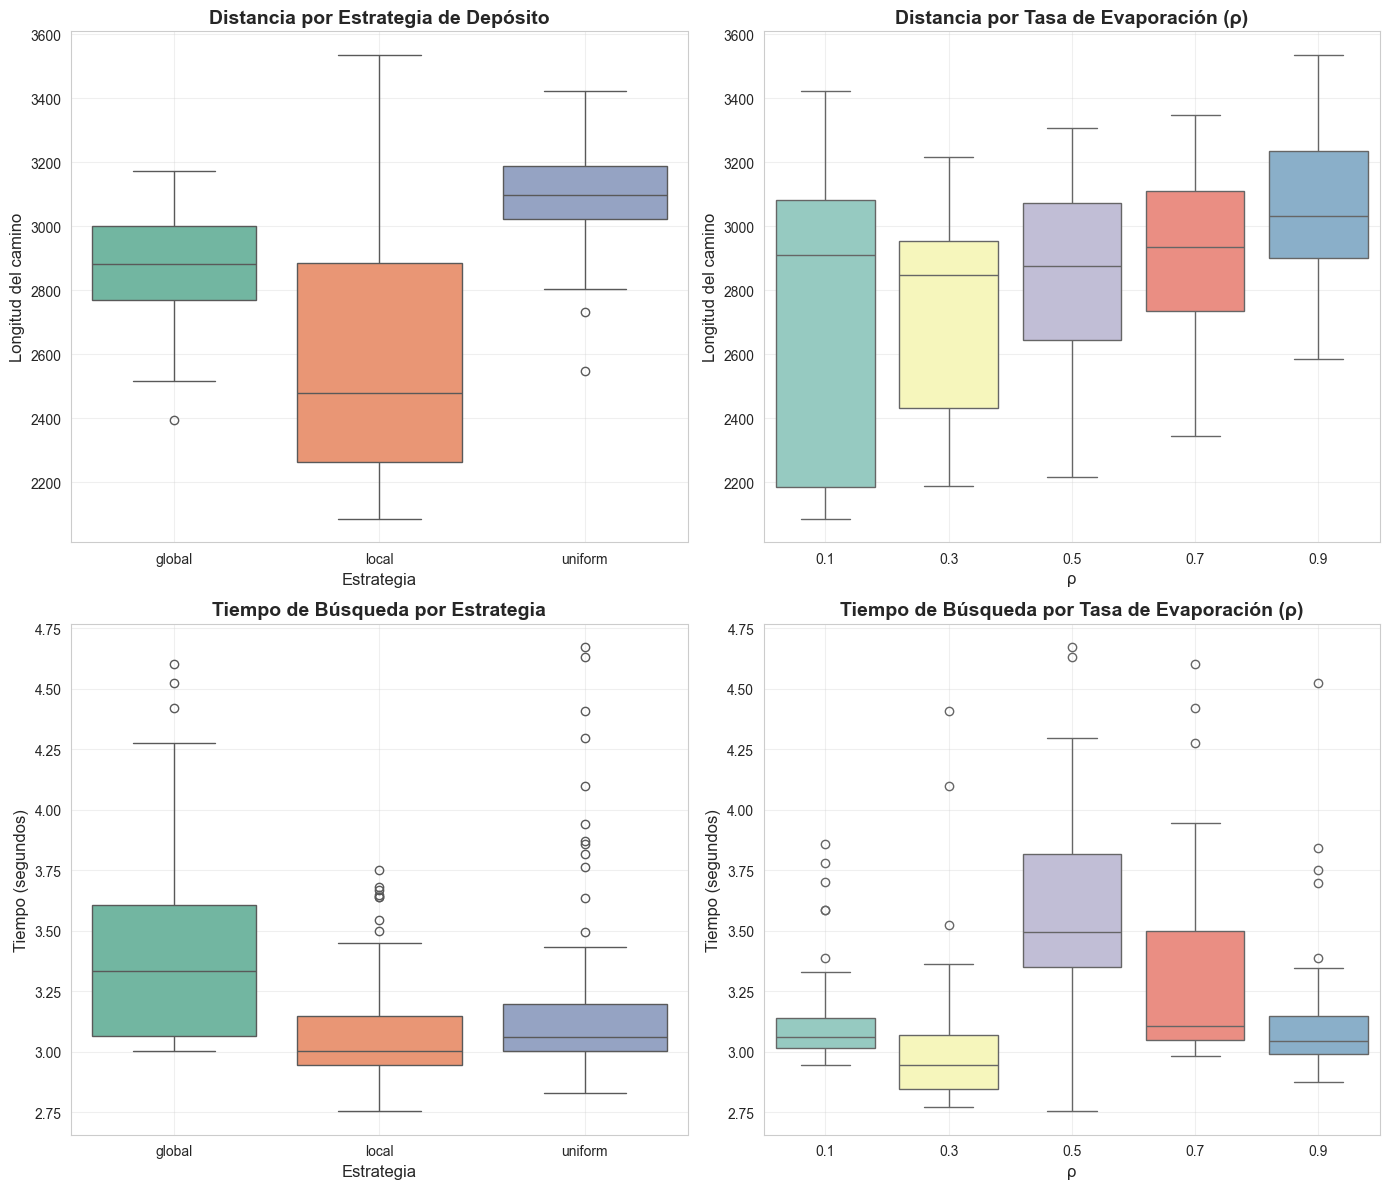

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Primero, preparar los datos para los boxplots de DISTANCIA
data_boxplot_dist = []

for rho in results:
    for strategy in results[rho]:
        distancias = results[rho][strategy]['best_dist']
        for dist in distancias:
            data_boxplot_dist.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Distancia': dist
            })

df_boxplot_dist = pd.DataFrame(data_boxplot_dist)

# Preparar los datos para los boxplots de TIEMPO
data_boxplot_time = []

for rho in results:
    for strategy in results[rho]:
        tiempos = results[rho][strategy]['best_time']
        for t in tiempos:
            data_boxplot_time.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Tiempo': t
            })

df_boxplot_time = pd.DataFrame(data_boxplot_time)

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 12)

# Crear figura con subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Distancia por Estrategia
sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distancia por Estrategia de Depósito', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Estrategia', fontsize=12)
axes[0, 0].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Distancia por ρ
sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Distancia por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('ρ', fontsize=12)
axes[0, 1].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tiempo por Estrategia
sns.boxplot(data=df_boxplot_time, x='Estrategia', y='Tiempo', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tiempo de Búsqueda por Estrategia', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Estrategia', fontsize=12)
axes[1, 0].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Tiempo por ρ
sns.boxplot(data=df_boxplot_time, x='ρ', y='Tiempo', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Tiempo de Búsqueda por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('ρ', fontsize=12)
axes[1, 1].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicio 2: Comparación AG vs ACO

Comparamos el Algoritmo Genético (AG) contra el ACO con la mejor configuración encontrada (`local`, ρ=0.1).

Para que la comparación sea justa, igualamos el **budget de evaluaciones**:
- ACO: 17 hormigas × 200 iteraciones = **3400 evaluaciones**
- AG: 170 individuos × 20 generaciones = **3400 evaluaciones**

El eje x de la curva de convergencia se normaliza al porcentaje del budget consumido.

In [ ]:
def ox_crossover(p1, p2, pc):
    if np.random.rand() >= pc:
        return p1.copy(), p2.copy()
    n = len(p1)
    a, b = sorted(np.random.choice(n, 2, replace=False))

    def build_child(donor, other):
        segment = set(donor[a:b+1])
        remaining = [c for c in np.roll(other, -(b+1)) if c not in segment]
        child = np.empty(n, dtype=int)
        child[a:b+1] = donor[a:b+1]
        positions = [(b+1+i) % n for i in range(n - (b - a + 1))]
        for pos, city in zip(positions, remaining):
            child[pos] = city
        return child

    return build_child(p1, p2), build_child(p2, p1)


def mutate_inversion(tour, pm):
    tour = tour.copy()
    if np.random.rand() < pm:
        a, b = sorted(np.random.choice(len(tour), 2, replace=False))
        tour[a:b+1] = tour[a:b+1][::-1]
    return tour


def selection_windows(pop_size, fitness, population):
    idx_sorted = np.argsort(fitness)
    selected_indices = []
    for i in range(pop_size):
        window_size = max(1, int(pop_size * (1 - i / pop_size)))
        pick = np.random.randint(0, window_size)
        selected_indices.append(idx_sorted[pick])
    return population[selected_indices]


def get_elites(population, fitness, n_elites):
    elite_indices = np.argsort(fitness)[:n_elites]
    return population[elite_indices].copy()


def fitness_tsp(population, dist_matrix):
    next_cities = np.roll(population, -1, axis=1)
    return dist_matrix[population, next_cities].sum(axis=1)


def run_evolution_tsp(pop_size, select_method, n_gen, pc, pm, n_elites, dist_matrix):
    n_cities = dist_matrix.shape[0]
    population = np.array([np.random.permutation(n_cities) for _ in range(pop_size)])
    history = []

    for gen in range(n_gen):
        fitness = fitness_tsp(population, dist_matrix)
        history.append(float(np.min(fitness)))

        new_population = list(get_elites(population, fitness, n_elites))
        mating_pool = select_method(pop_size, fitness, population)

        idx_padre = 0
        while len(new_population) < pop_size:
            p1 = mating_pool[idx_padre % pop_size]
            p2 = mating_pool[(idx_padre + 1) % pop_size]
            c1, c2 = ox_crossover(p1, p2, pc)
            new_population.append(mutate_inversion(c1, pm))
            if len(new_population) < pop_size:
                new_population.append(mutate_inversion(c2, pm))
            idx_padre += 2

        population = np.array(new_population)

    return population, history

In [ ]:
import time
import seaborn as sns

N_REPS = 20

results_aco, results_ga = [], []
history_aco_all, history_ga_all = [], []

# Budget equivalente: ACO → 17 hormigas × 200 iters = 3400 evaluaciones
#                     GA  → 170 individuos × 20 generaciones = 3400 evaluaciones
print(f"Corriendo {N_REPS} repeticiones de cada algoritmo...")
for i in range(N_REPS):
    # ACO — mejor config del análisis previo
    t0 = time.time()
    aco_cmp = ACO(strategy='local')
    _, dist_aco, hist_aco = aco_cmp.run(rho=0.1, D=D, n_ants=17, max_iters=200)
    results_aco.append({'dist': dist_aco, 'time': time.time() - t0})
    history_aco_all.append(hist_aco)

    # GA
    t0 = time.time()
    pop_final, hist_ga = run_evolution_tsp(
        pop_size=170, select_method=selection_windows,
        n_gen=20, pc=0.85, pm=0.15, n_elites=2, dist_matrix=D
    )
    best_ga = np.min(fitness_tsp(pop_final, D))
    results_ga.append({'dist': best_ga, 'time': time.time() - t0})
    history_ga_all.append(hist_ga)

    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{N_REPS} completadas")

print("Listo.")

In [ ]:
# ── Tabla resumen ───────────────────────────────────────────────────────────
print(f"\n{'Método':<8} {'Media':>10} {'Std':>10} {'Mejor':>10} {'Tiempo medio':>14}")
print("─" * 55)
for nombre, res in [('ACO', results_aco), ('GA', results_ga)]:
    dists = [r['dist'] for r in res]
    times = [r['time'] for r in res]
    print(f"{nombre:<8} {np.mean(dists):>10.1f} {np.std(dists):>10.1f} "
          f"{np.min(dists):>10.1f} {np.mean(times):>14.3f}s")

# ── Curvas de convergencia (x normalizado al budget total) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, histories, color in [('ACO (local, ρ=0.1)', history_aco_all, 'steelblue'),
                                   ('GA (OX + inversión)', history_ga_all, 'tomato')]:
    arr = np.array(histories, dtype=float)
    media = arr.mean(axis=0)
    std   = arr.std(axis=0)
    x = np.linspace(0, 100, len(media))   # % del budget consumido
    axes[0].plot(x, media, label=nombre, color=color)
    axes[0].fill_between(x, media - std, media + std, alpha=0.2, color=color)

axes[0].set_xlabel('% del budget de evaluaciones')
axes[0].set_ylabel('Mejor distancia encontrada')
axes[0].set_title('Convergencia: ACO vs GA — gr17')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Boxplot distancias finales ──────────────────────────────────────────────
data_bp = (
    [{'Método': 'ACO', 'Distancia': r['dist']} for r in results_aco] +
    [{'Método': 'GA',  'Distancia': r['dist']} for r in results_ga]
)
df_bp = pd.DataFrame(data_bp)
sns.boxplot(data=df_bp, x='Método', y='Distancia', palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Distribución de distancias finales')
axes[1].set_ylabel('Longitud del tour')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()